In [1]:
import json
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
file_path = "../data/annotations/instances_val2017.json"

with open(file_path, "r") as f:
    coco = json.load(f)


In [3]:
cat_map = {cat["id"]: cat["name"] for cat in coco["categories"]}


In [4]:
img_info = coco["images"][10]
img_id = img_info["id"]
width = img_info["width"]
height = img_info["height"]

print(img_info)


{'license': 3, 'file_name': '000000296649.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000296649.jpg', 'height': 427, 'width': 640, 'date_captured': '2013-11-15 15:26:19', 'flickr_url': 'http://farm4.staticflickr.com/3577/3491669985_d81e1050c6_z.jpg', 'id': 296649}


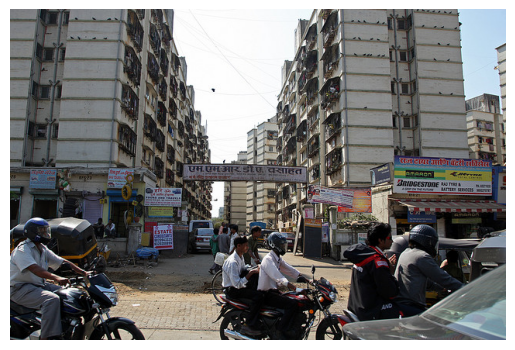

In [46]:
image_path = "../data/images/val2017/" + img_info["file_name"]

image = cv2.imread(image_path)

if image is None:
    print("Image not found at:", image_path)
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.axis("off")

In [6]:
anns = [a for a in coco["annotations"] if a["image_id"] == img_id]


In [48]:
mask = np.zeros((height, width), dtype=np.uint8)


In [ ]:
target_class = "person"

for ann in anns:
    if cat_map[ann["category_id"]] == target_class:

        segmentation = ann["segmentation"]

        if isinstance(segmentation, list):
            for seg in segmentation:
                polygon = np.array(seg).reshape((-1, 2)).astype(np.int32)
                cv2.fillPoly(mask, [polygon], 255)



(-0.5, 639.5, 426.5, -0.5)

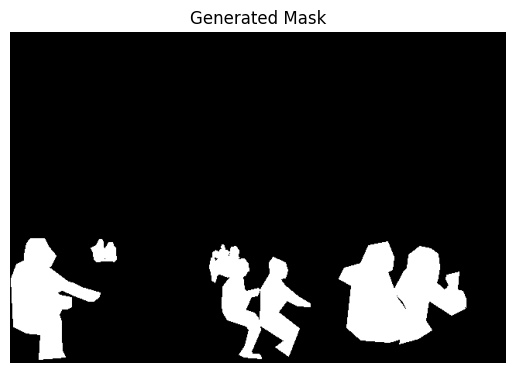

In [50]:
plt.imshow(mask, cmap="gray")
plt.title("Generated Mask")
plt.axis("off")


In [ ]:
import os

os.makedirs("../data/masks", exist_ok=True)

mask_path = "../data/masks/mask10.png"
cv2.imwrite(mask_path, mask)

print("Mask saved at:", mask_path)


Mask saved at: ../data/masks/mask10.png


In [ ]:
import cv2
import numpy as np

original = cv2.imread("../data/images/val2017/000000296649.jpg")
mask = cv2.imread("../data/masks/mask10.png", cv2.IMREAD_GRAYSCALE)

_, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

if binary_mask.shape != original.shape[:2]:
    binary_mask = cv2.resize(binary_mask, (original.shape[1], original.shape[0]))

binary_mask = binary_mask.astype(np.uint8)

isolated = cv2.bitwise_and(original, original, mask=binary_mask)

isolated_path = "../data/masks/isolated10.png"
success = cv2.imwrite(isolated_path, isolated)

if success:
    print("Isolated image saved at:", isolated_path)

Isolated image saved at: ../data/masks/isolated10.png


In [38]:
img_info = coco["images"][101]
img_id = img_info["id"]
width = img_info["width"]
height = img_info["height"]

print(img_info)

{'license': 4, 'file_name': '000000544519.jpg', 'coco_url': 'http://images.cocodataset.org/val2017/000000544519.jpg', 'height': 427, 'width': 640, 'date_captured': '2013-11-21 19:25:58', 'flickr_url': 'http://farm5.staticflickr.com/4097/4947025740_1bb4b64539_z.jpg', 'id': 544519}


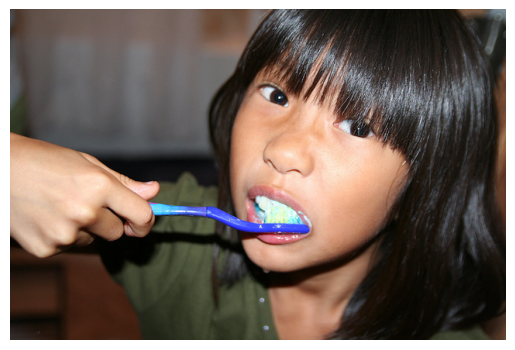

In [44]:
image_path = "../data/images/val2017/" + img_info["file_name"]

image = cv2.imread(image_path)

if image is None:
    print("Image not found at:", image_path)
else:
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image)
    plt.axis("off")

In [39]:
anns = [a for a in coco["annotations"] if a["image_id"] == img_id]

In [40]:
mask = np.zeros((height, width), dtype=np.uint8)

In [41]:
target_class = "person"

for ann in anns:
    if cat_map[ann["category_id"]] == target_class:

        segmentation = ann["segmentation"]

        # Check if segmentation is polygon
        if isinstance(segmentation, list):
            for seg in segmentation:
                polygon = np.array(seg).reshape((-1, 2)).astype(np.int32)
                cv2.fillPoly(mask, [polygon], 255)

(-0.5, 639.5, 426.5, -0.5)

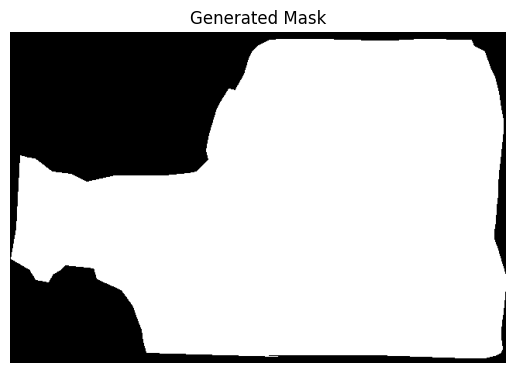

In [42]:
plt.imshow(mask, cmap="gray")
plt.title("Generated Mask")
plt.axis("off")

In [43]:
cv2.imwrite("../data/masks/sample_mask.png", mask)

False

In [27]:
import os

image_path = "../data/images/val2017/" + img_info["file_name"]

print("Image path:", image_path)
print("File exists?", os.path.exists(image_path))


Image path: ../data/images/val2017/000000544519.jpg
File exists? True


In [6]:
import os
import numpy as np
import cv2

os.makedirs("../data/masks", exist_ok=True)

target_class = "person"

for img_info in coco["images"][:300]:

    img_id = img_info["id"]
    width = img_info["width"]
    height = img_info["height"]

    mask = np.zeros((height, width), dtype=np.uint8)

    anns = [a for a in coco["annotations"] if a["image_id"] == img_id]

    for ann in anns:
        if cat_map[ann["category_id"]] == target_class:

            segmentation = ann["segmentation"]

            if isinstance(segmentation, list):
                for seg in segmentation:
                    polygon = np.array(seg).reshape((-1, 2)).astype(np.int32)
                    cv2.fillPoly(mask, [polygon], 255)

    mask_name = img_info["file_name"].replace(".jpg", ".png")
    cv2.imwrite(f"../data/masks/{mask_name}", mask)

print("Mask generation complete.")


Mask generation complete.
